# Zadanie dodatkowe

## Importy

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ['KAGGLE_USERNAME'] = "michawilczkowski"
os.environ['KAGGLE_KEY'] = os.getenv('kaggle_api_token')

In [47]:
from kagglehub import dataset_download
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, jaccard_score
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.nn import BCELoss
from torch.optim import Adam
import torch

## Eksploracja danych

In [3]:
path = dataset_download("julinmaloof/the-oxfordiiit-pet-dataset")

In [4]:
path

'/home/michal/.cache/kagglehub/datasets/julinmaloof/the-oxfordiiit-pet-dataset/versions/1'

In [5]:
print(os.listdir(path + '/annotations/trimaps'))
print(os.listdir(path + '/images/'))

['Abyssinian_1.png', 'Abyssinian_10.png', 'Abyssinian_100.png', 'Abyssinian_101.png', 'Abyssinian_102.png', 'Abyssinian_103.png', 'Abyssinian_104.png', 'Abyssinian_105.png', 'Abyssinian_106.png', 'Abyssinian_107.png', 'Abyssinian_108.png', 'Abyssinian_109.png', 'Abyssinian_11.png', 'Abyssinian_110.png', 'Abyssinian_111.png', 'Abyssinian_112.png', 'Abyssinian_113.png', 'Abyssinian_114.png', 'Abyssinian_115.png', 'Abyssinian_116.png', 'Abyssinian_117.png', 'Abyssinian_118.png', 'Abyssinian_119.png', 'Abyssinian_12.png', 'Abyssinian_120.png', 'Abyssinian_121.png', 'Abyssinian_122.png', 'Abyssinian_123.png', 'Abyssinian_124.png', 'Abyssinian_125.png', 'Abyssinian_126.png', 'Abyssinian_127.png', 'Abyssinian_128.png', 'Abyssinian_129.png', 'Abyssinian_13.png', 'Abyssinian_130.png', 'Abyssinian_131.png', 'Abyssinian_132.png', 'Abyssinian_133.png', 'Abyssinian_134.png', 'Abyssinian_135.png', 'Abyssinian_136.png', 'Abyssinian_137.png', 'Abyssinian_138.png', 'Abyssinian_139.png', 'Abyssinian_14.

In [6]:
print('Liczba probek w zbiorze zdjec:', len(os.listdir(path + '/images/')))
print('Liczba probek w zbiorze masek:', len(os.listdir(path + '/annotations/trimaps/')))
print('Liczba plikow .mat:', sum([int('mat' in x) for x in os.listdir(path + '/images/')]))
#W zdjeciach sa trzy pliki z rozszerzeniem .mat, ktore bede ignorowal

Liczba probek w zbiorze zdjec: 7393
Liczba probek w zbiorze masek: 7390
Liczba plikow .mat: 3


In [7]:
[Image.open(path + '/annotations/trimaps/' + img).size for img in os.listdir(path + '/annotations/trimaps/')[:5]]
# Obrazy sa roznej wielkosci

[(600, 400), (375, 500), (394, 500), (450, 313), (500, 465)]

In [8]:
mask = Image.open(path + '/annotations/trimaps/staffordshire_bull_terrier_171.png')
img = Image.open(path + '/images/staffordshire_bull_terrier_171.jpg')
print("Rozmiar zdjecia: ", img.size)
print("Rozmiar maski:", mask.size)
print("Wartosci w masce:", np.unique(np.array(mask)))

Rozmiar zdjecia:  (500, 375)
Rozmiar maski: (500, 375)
Wartosci w masce: [1 2 3]


1 = zwierze

2 = tlo

3 = granica

Redukuje ilosc obrazow poniewaz mam 121 077 760 pikseli. Kazda klasa bedzie miala po 25 zdjec.

In [9]:
unique_images_names = set(["_".join(name.split("_")[:-1]) for name in os.listdir(path + '/annotations/trimaps')])

In [10]:
all_images_names = []
image_count = 10

all_files = os.listdir(path + '/annotations/trimaps')

for name in unique_images_names:
    to_add = 1
    for _ in range(image_count):
        while True:
            if name + '_' + str(to_add) + '.png' not in all_files:
                to_add += 1
            else:
                break
        all_images_names.append(name + '_' + str(to_add))
        to_add += 1

In [11]:
all_masks = [np.array(Image.open(path + '/annotations/trimaps/' + mask + '.png')) for mask in all_images_names]

In [12]:
mask_coverage = [np.sum(mask != 1) / (mask.shape[0] * mask.shape[1]) for mask in all_masks]

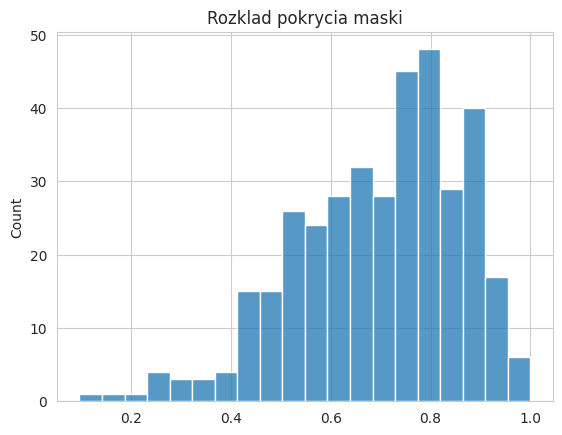

In [13]:
sns.histplot(mask_coverage, bins=20)
plt.title('Rozklad pokrycia maski')
plt.show()

In [14]:
all_images = [np.array(Image.open(path + '/images/' + image + '.jpg')) for image in all_images_names]

In [15]:
mean_brightness = [np.mean(img) for img in all_images]

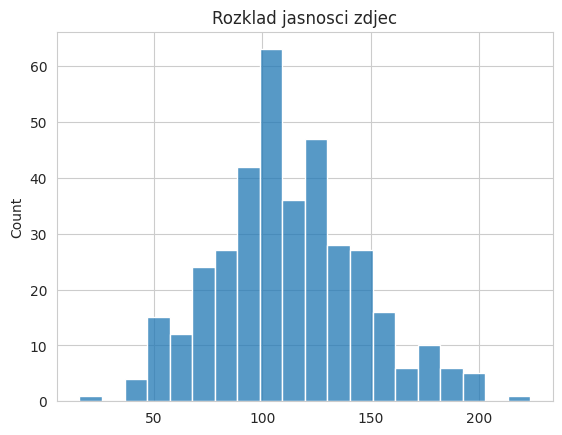

In [16]:
sns.histplot(mean_brightness, bins=20)
plt.title('Rozklad jasnosci zdjec')
plt.show()

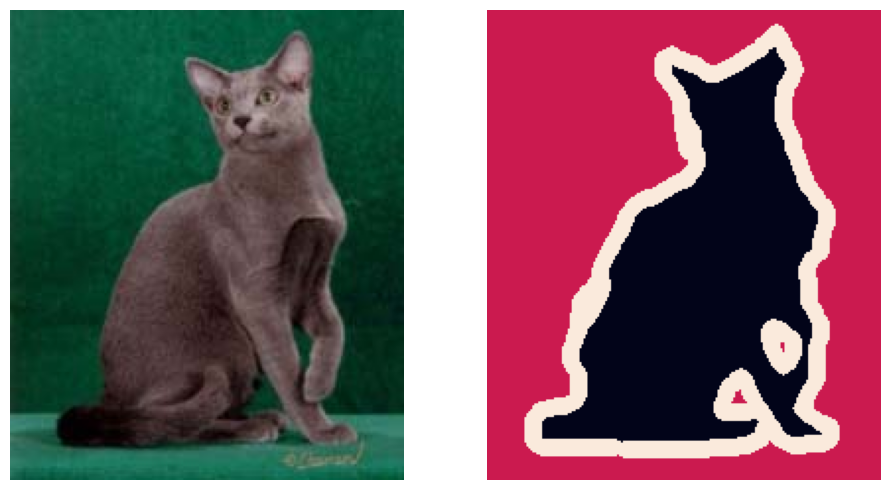

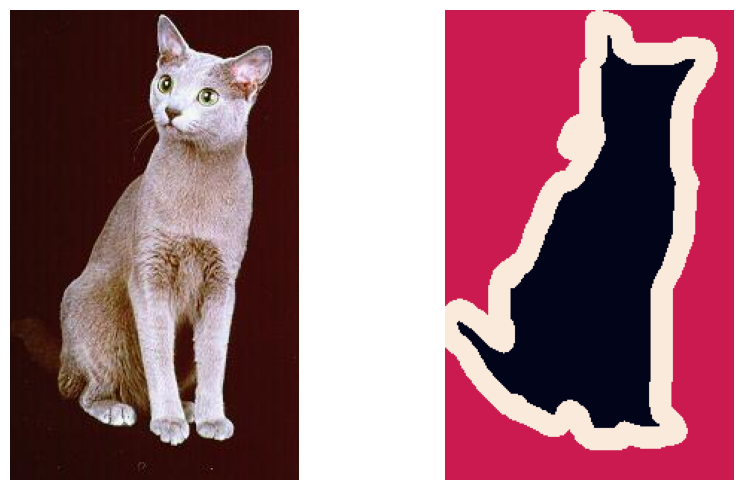

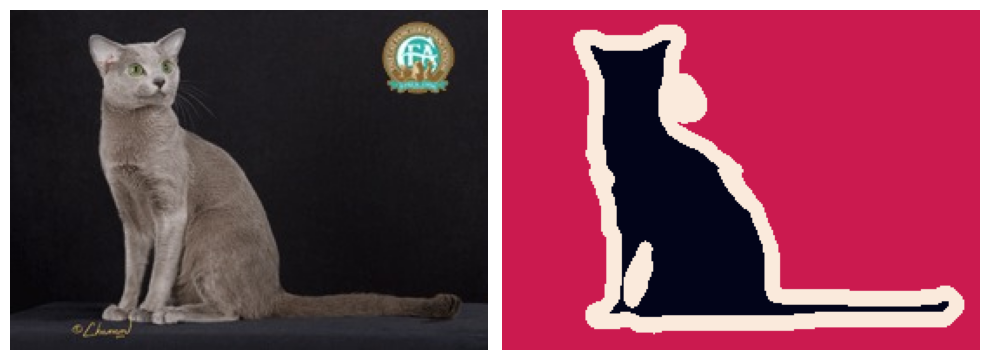

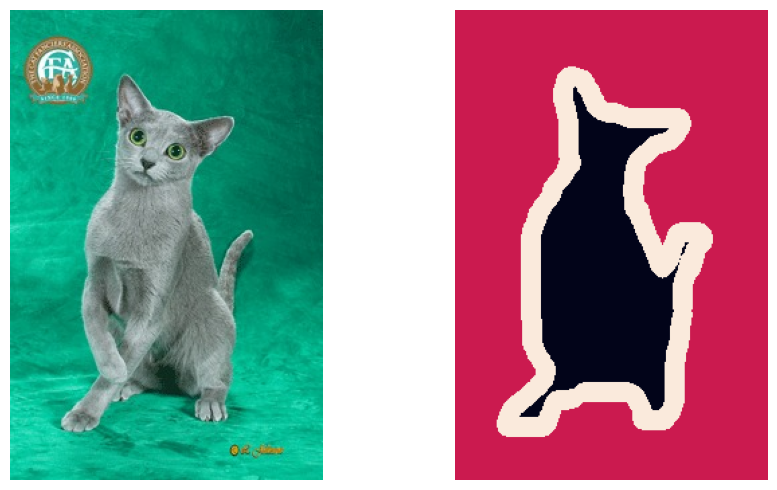

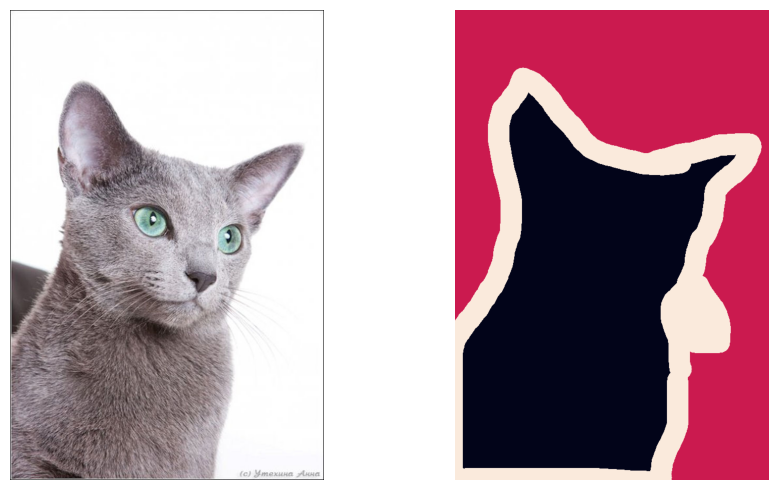

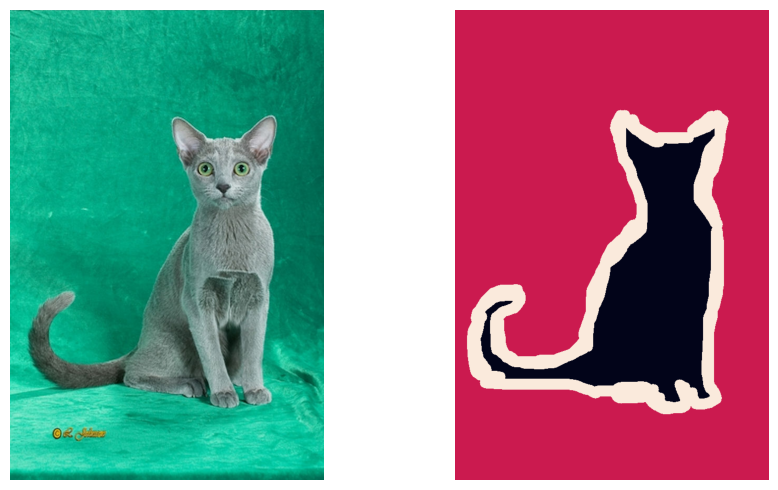

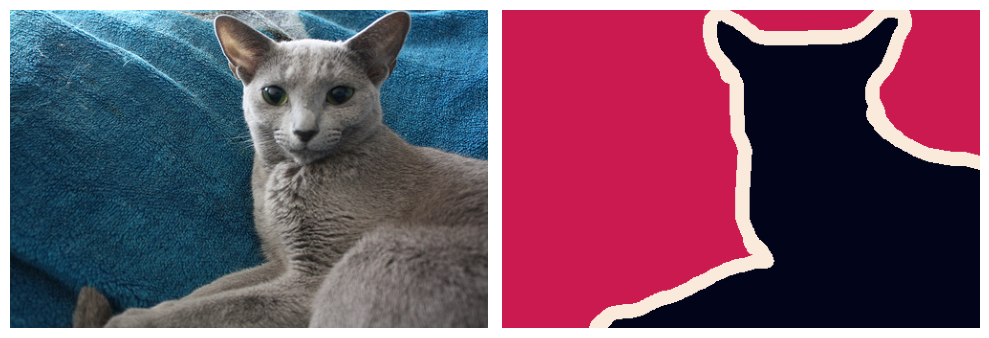

In [17]:
for i in range(7):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(all_images[i])
    axes[0].axis('off')
    axes[1].imshow(all_masks[i])
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

## Przygotowanie danych

In [18]:
def resize_image(img, to_rgb=True):
    if to_rgb:
        return np.array(Image.fromarray(img).convert('RGB').resize((128, 128)))
    return np.array(Image.fromarray(img).resize((128, 128)))

In [19]:
len(all_masks)

370

In [20]:
y = []
for mask in all_masks:
    mask[mask == 2] = 0
    mask[mask != 0] = 1
    mask = resize_image(mask, False)
    y.append(mask.flatten())

y = np.array(y).flatten()

In [21]:
np.array(Image.fromarray(all_images[31]).convert('RGB').resize((128, 128)))

array([[[ 35,  34,  35],
        [ 48,  44,  46],
        [ 42,  32,  30],
        ...,
        [ 50,  43,  30],
        [ 50,  44,  31],
        [ 53,  47,  36]],

       [[ 54,  53,  54],
        [ 53,  42,  42],
        [ 43,  29,  23],
        ...,
        [ 81,  74,  66],
        [ 68,  63,  54],
        [ 64,  59,  51]],

       [[ 79,  78,  77],
        [ 58,  50,  48],
        [ 68,  62,  60],
        ...,
        [ 75,  70,  67],
        [ 52,  48,  45],
        [ 83,  82,  79]],

       ...,

       [[152, 143, 137],
        [163, 147, 142],
        [166, 146, 136],
        ...,
        [102,  97,  73],
        [102,  99,  76],
        [119, 115,  87]],

       [[154, 144, 138],
        [156, 138, 126],
        [148, 127, 105],
        ...,
        [103,  85,  57],
        [107,  89,  59],
        [103,  95,  68]],

       [[143, 132, 119],
        [134, 112,  86],
        [139, 121, 106],
        ...,
        [ 91,  70,  43],
        [ 94,  77,  53],
        [ 87,  76,  57]]

In [22]:
X = np.array([
    resize_image(img).reshape((-1, 3))
for img in all_images]).reshape((-1, 3))

In [23]:
X.shape

(6062080, 3)

In [24]:
y.shape

(6062080,)

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.25, random_state=42)

In [26]:
X_train.shape

(3637248, 3)

## Modele bazowe

In [27]:
model_gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.5, max_depth=4, random_state=42)
model_gb.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.5
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,4
,min_impurity_decrease,0.0
,init,None


In [28]:
model_rf = RandomForestClassifier(n_estimators=1000, max_depth=3, random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train)

,n_estimators,1000
,criterion,'gini'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
preds = model_gb.predict(X_test)
print('Gradient boosting')
print(f'Accuracy: {accuracy_score(y_test, preds):.3f}')
print(f'IOU: {jaccard_score(y_test, preds, average='binary'):.3f}')

Gradient boosting
Accuracy: 0.667
IOU: 0.463


In [30]:
preds = model_rf.predict(X_test)
print('Random forest')
print(f'Accuracy: {accuracy_score(y_test, preds):.3f}')
print(f'IOU: {jaccard_score(y_test, preds, average='binary'):.3f}')

Random forest
Accuracy: 0.571
IOU: 0.000


Random forest nie radzi sobie z tym zadaniem

Gradient boosting forest juz troche lepszy, ale trenuje sie o wiele dluzej.

Niezaleznie, co zmienilem w random forest nie bylo znaczacej poprawy w obu modelach.

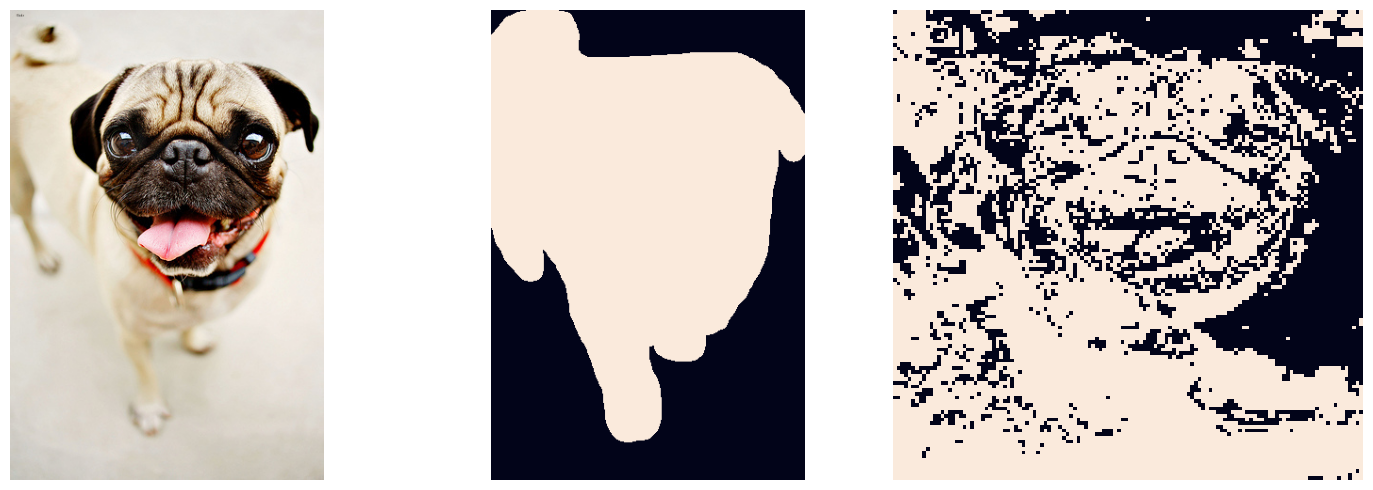

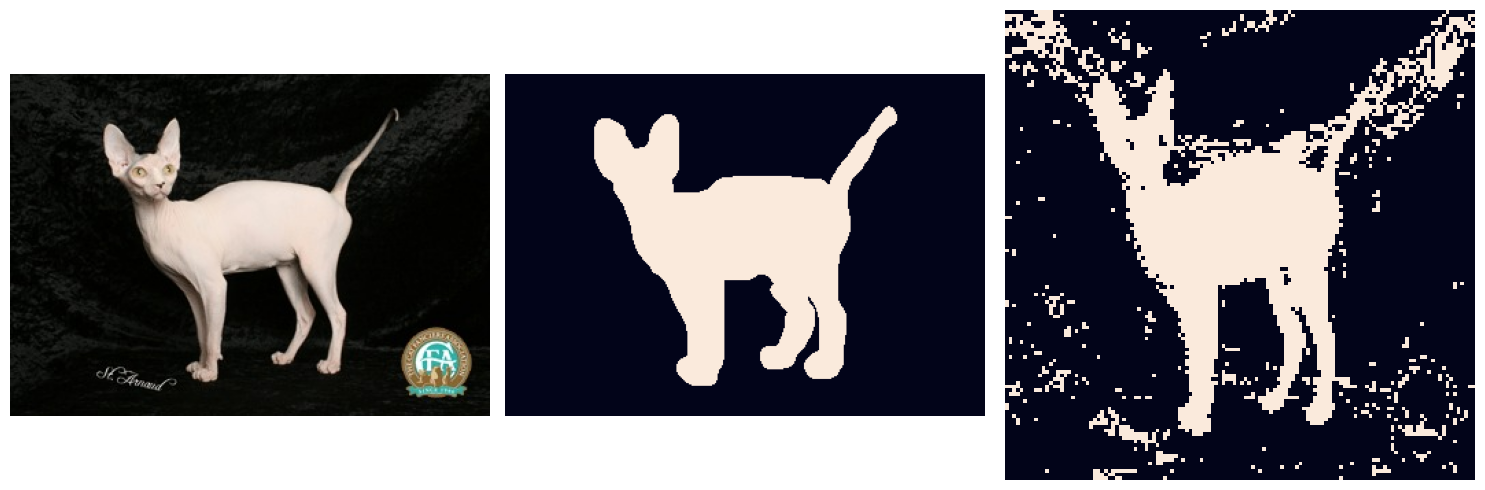

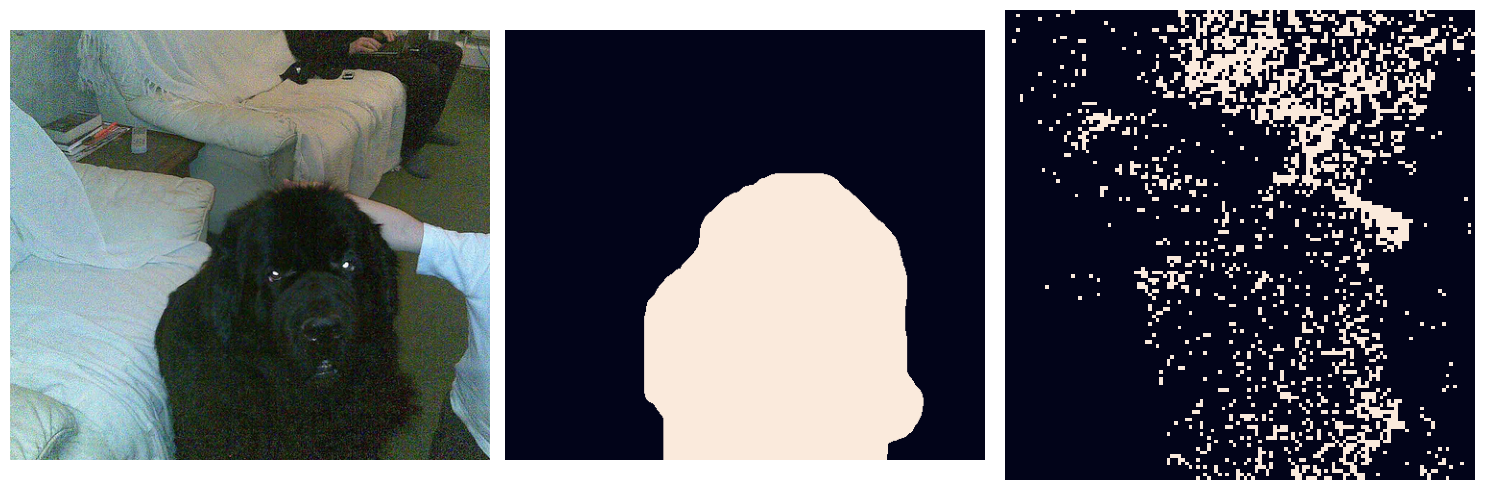

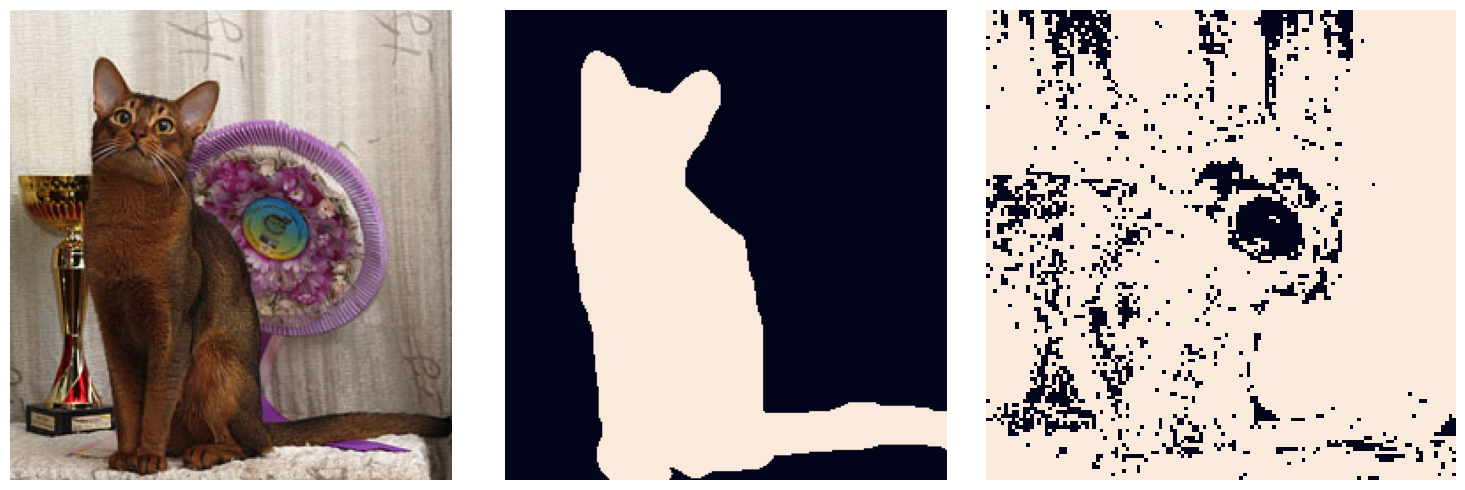

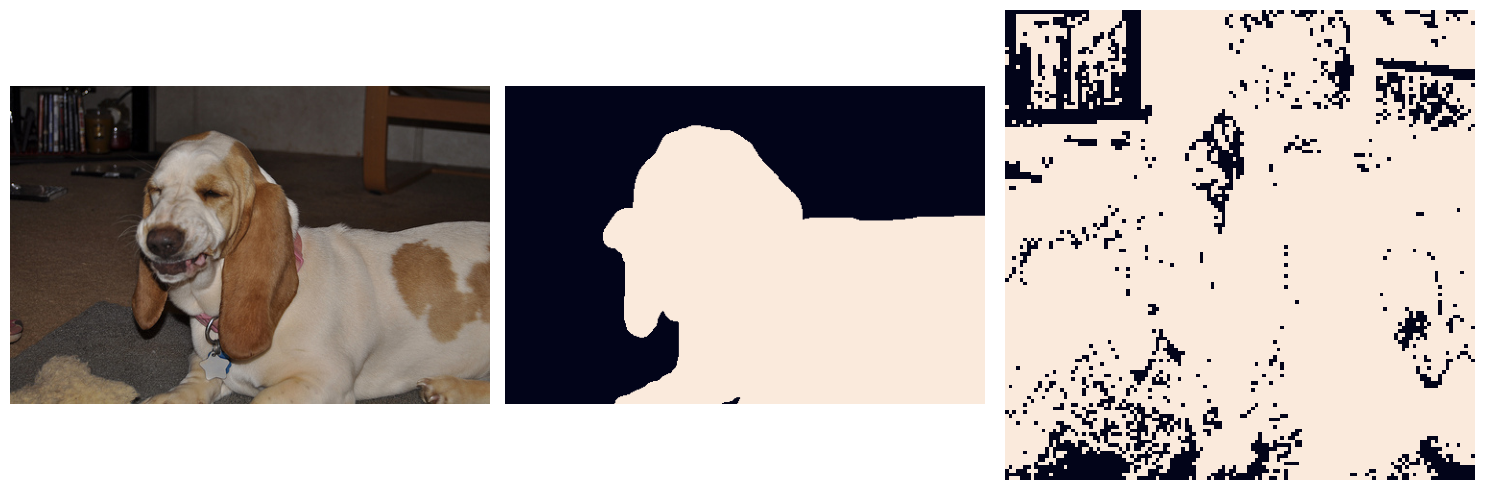

In [31]:
for _ in range(5):
    i = np.random.randint(len(all_images))
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    pred_mask = model_gb.predict(resize_image(all_images[i]).reshape((-1, 3))).reshape((128, 128))

    axes[0].imshow(all_images[i])
    axes[0].axis('off')
    axes[1].imshow(all_masks[i])
    axes[1].axis('off')
    axes[2].imshow(pred_mask)
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

Model GB radzi sobie dobrze jezeli roznica kolorow miedzy zwierzeciem, a tlem jest duza. Najlepiej, jezeli to jednolite tlo.

## Siec neuronowa

In [32]:
class PixelMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [49]:
class PixelDataset(Dataset):
    def __init__(self, X, y):
        super().__init__()
        self.X = torch.tensor(X, dtype=torch.float32) / 255.0
        self.y = torch.tensor(y, dtype=torch.float32)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

    def __len__(self):
        return len(self.X)


In [50]:
train_dataset = PixelDataset(X_train, y_train)
test_dataset = PixelDataset(X_test, y_test)
val_dataset = PixelDataset(X_val, y_val)

In [51]:
train_dataloader = DataLoader(train_dataset, batch_size=4096, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=4096, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=4096, shuffle=True)

## Trening

In [53]:
def train_loop(model, criterion, optimizer, dataloader):
    model.train()
    for features, labels in dataloader:
        preds = model.forward(features).squeeze()
        loss = criterion(preds, labels)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

In [63]:
def test_loop(model, criterion, dataloader):
    model.eval()
    correct = 0
    test_loss = 0

    for features, labels in dataloader:
        preds = model.forward(features).squeeze()
        test_loss += criterion(preds, labels).item()
        predicted = (preds > 0.5).float()
        correct += (predicted == labels).sum().item()

    print(f'Loss: {test_loss / len(dataloader):.4f}')
    print(f'Accuracy: {correct / len(dataloader.dataset):.4f}')

In [66]:
model = PixelMLP()
criterion = BCELoss()
optimizer = Adam(params=model.parameters())

In [67]:
running_loss = 0
epochs = 10

model.train()
for epoch in range(epochs):
    train_loop(model, criterion, optimizer, train_dataloader)
    test_loop(model, criterion, test_dataloader)

Loss: 0.6061
Accuracy: 0.6501
Loss: 0.6018
Accuracy: 0.6543
Loss: 0.6005
Accuracy: 0.6565
Loss: 0.5996
Accuracy: 0.6576
Loss: 0.5989
Accuracy: 0.6591
Loss: 0.5985
Accuracy: 0.6579
Loss: 0.5980
Accuracy: 0.6590
Loss: 0.5977
Accuracy: 0.6586
Loss: 0.5973
Accuracy: 0.6592
Loss: 0.5970
Accuracy: 0.6591


In [69]:
torch.save(model.state_dict(), './model')

### Wybieram accuracy, bo prosciej zaimplementowac. Generalnie IoU wydaje sie lepsze tutaj, bo zostalo stworzone do tego typu zadan